# 05 Similar-device diagnosis — Jsc main analysis and Voc secondary audit

## Purpose

The source-aware experiment can show that prediction degrades for unseen literature sources, but it cannot determine why. This notebook therefore asks:

> **Within devices that are similar under the principal recorded material and device descriptors, does the remaining recorded descriptor space align with target variation?**

### Main analysis: Jsc

1. Reproduce the established similar-device definition and Jsc group numbering.
2. Select groups with:
   - `n >= 10`
   - Jsc range `> 10 mA/cm²`
3. For every selected group, remove descriptors that are constant within that group.
4. Project the remaining **canonical 207-feature all-in representation** with UMAP.
5. Export the descriptors that actually vary in each group for manual interpretation.

The three diagnostic categories—clear target-aligned structure, mixed/confounded structure, and descriptor-insufficient structure—remain **manual interpretations** of the plots and feature inventories. The notebook does not assign categories automatically.

### Secondary audit: Voc

Voc is retained only as a compact consistency audit using its previously defined similar-device rule and the established `0.3 V` range threshold. It is **not** subjected to another full three-category UMAP case-study analysis, because the detailed diagnostic narrative is centred on Jsc.

### Important methodological change

The obsolete “final-50 first, old all-in fallback” design is removed. The diagnosis now uses the canonical 207 descriptors directly, because this experiment asks whether **any permitted recorded descriptor** can explain within-group variation—not whether a compressed predictive subset is sufficient.


In [1]:
# ============================================================
# 0. Imports and settings
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    import umap
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "The package 'umap-learn' is required. "
        "Install it in the notebook environment with: %pip install umap-learn"
    ) from exc

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_PATH = Path("df_base.csv")
OUTPUT_DIR = Path("similar_device_diagnosis_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
MAX_MISSING_RATIO = 0.50
EXPECTED_ALLIN_FEATURES = 207

# Established Jsc diagnosis rule.
JSC_ANALYSIS_MIN_N = 10
JSC_INCONSISTENT_MIN_N = 5
JSC_RANGE_THRESHOLD = 10.0

# Established Voc inconsistency-audit rule.
VOC_AUDIT_MIN_N = 5
VOC_RANGE_THRESHOLD = 0.30

# UMAP setting retained from the previous diagnosis.
UMAP_MAX_NEIGHBORS = 8
UMAP_MIN_DIST = 0.05

df = pd.read_csv(DATA_PATH, low_memory=False)

print("Loaded:", DATA_PATH.resolve())
print("Shape:", df.shape)


/Users/rosylu/Desktop/Project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded: /Users/rosylu/Desktop/Project/df_base.csv
Shape: (3953, 411)


## 1. Build the two agreed Level-3 descriptors and canonical 207 features

This is the same rule-based all-in definition used in the stability, source-aware, component-selection, and PCE notebooks:

- begin with eligible `df_base.csv` descriptors having `< 50%` NaN missingness;
- remove outcome leakage, reference identity, schema/raw-data links, and preprocessing-only helper/QC fields;
- replace five duplicated raw thickness/bandgap representations one-for-one with clean versions;
- include the three existing layer-count helpers;
- add the two agreed Level-3 descriptors.


In [2]:
# ============================================================
# 1. Canonical feature construction
# ============================================================

NUMERIC_COLUMNS = [
    "jv.default_Jsc",
    "jv.default_Voc",
    "jv.default_FF",
    "jv.default_PCE",
    "PVK_thickness_clean",
    "ETL_thickness_clean",
    "HTL_thickness_clean",
    "BC_thickness_clean",
    "perovskite_bandgap_clean",
    "ETL_n_layers",
    "HTL_n_layers",
    "BC_n_layers",
]

for column in NUMERIC_COLUMNS:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")


def num_col(frame, column):
    if column in frame.columns:
        return pd.to_numeric(frame[column], errors="coerce")
    return pd.Series(np.nan, index=frame.index)


def safe_divide(numerator, denominator):
    return (
        numerator / denominator.replace(0, np.nan)
    ).replace([np.inf, -np.inf], np.nan)


pvk = num_col(df, "PVK_thickness_clean")
etl = num_col(df, "ETL_thickness_clean")
htl = num_col(df, "HTL_thickness_clean")
bc = num_col(df, "BC_thickness_clean")

df["Absorber_to_ETL_ratio"] = safe_divide(pvk, etl)
df["ff_PVK_fraction_of_total_stack"] = safe_divide(
    pvk,
    pvk + etl + htl + bc,
)

PREPROCESSING_ADDED_COLUMNS = {
    "ETL_layers", "ETL_thickness_values", "ETL_n_layers",
    "ETL_n_thickness", "ETL_valid",
    "HTL_layers", "HTL_thickness_values", "HTL_n_layers",
    "HTL_n_thickness", "HTL_valid",
    "BC_layers", "BC_thickness_values", "BC_n_layers",
    "BC_n_thickness", "BC_valid",
    "ETL_thickness_clean", "HTL_thickness_clean", "BC_thickness_clean",
    "PVK_thickness_clean", "PVK_thickness_note", "PVK_valid",
    "all_layer_match", "perovskite_bandgap_clean", "baseline_complete",
}

DIRECT_OUTCOME_COLUMNS = {
    "jv.default_PCE", "jv.default_Jsc", "jv.default_Voc", "jv.default_FF",
    "jv.forward_scan_PCE", "jv.forward_scan_Jsc",
    "jv.forward_scan_Voc", "jv.forward_scan_FF",
    "jv.reverse_scan_PCE", "jv.reverse_scan_Jsc",
    "jv.reverse_scan_Voc", "jv.reverse_scan_FF",
    "jv.forward_scan_Vmp", "jv.forward_scan_Jmp",
    "jv.reverse_scan_Vmp", "jv.reverse_scan_Jmp",
    "jv.forward_scan_series_resistance",
    "jv.forward_scan_shunt_resistance",
    "jv.reverse_scan_series_resistance",
    "jv.reverse_scan_shunt_resistance",
    "jv.hysteresis_index",
    "stabilised.performance_PCE", "stabilised.performance_Jsc",
    "stabilised.performance_Voc", "stabilised.performance_FF",
    "stabilised.performance_Jmp", "stabilised.performance_Vmp",
    "stabilised.performance_procedure_metrics",
    "eqe.integrated_Jsc",
    "stability.PCE_burn_in_observed",
    "outdoor.PCE_burn_in_observed",
}

RAW_TO_CLEAN_REPLACEMENTS = {
    "perovskite.band_gap": "perovskite_bandgap_clean",
    "perovskite.thickness": "PVK_thickness_clean",
    "etl.thickness": "ETL_thickness_clean",
    "htl.thickness_list": "HTL_thickness_clean",
    "backcontact.thickness_list": "BC_thickness_clean",
}

LEVEL2_HELPERS = [
    "ETL_n_layers",
    "HTL_n_layers",
    "BC_n_layers",
]

LEVEL3_FEATURES = [
    "Absorber_to_ETL_ratio",
    "ff_PVK_fraction_of_total_stack",
]

ALL_TARGET_COLUMNS = [
    "jv.default_Jsc",
    "jv.default_Voc",
    "jv.default_FF",
    "jv.default_PCE",
]

missing_ratio = df.isna().mean()

eligible_raw_features = [
    column
    for column in df.columns
    if missing_ratio[column] < MAX_MISSING_RATIO
    and column not in PREPROCESSING_ADDED_COLUMNS
    and column not in DIRECT_OUTCOME_COLUMNS
    and column not in ALL_TARGET_COLUMNS
    and column not in LEVEL3_FEATURES
    and column != "m_def"
    and not column.startswith("ref.")
    and not column.endswith("link_raw_data")
]

ALLIN_FEATURES = [
    RAW_TO_CLEAN_REPLACEMENTS.get(column, column)
    for column in eligible_raw_features
]
ALLIN_FEATURES += LEVEL2_HELPERS + LEVEL3_FEATURES

required_features = (
    list(RAW_TO_CLEAN_REPLACEMENTS.values())
    + LEVEL2_HELPERS
    + LEVEL3_FEATURES
)
missing_required = [
    feature for feature in required_features
    if feature not in df.columns
]
if missing_required:
    raise ValueError(
        "Missing canonical clean/helper/Level-3 features: "
        + ", ".join(missing_required)
    )

assert len(eligible_raw_features) == 202
assert len(ALLIN_FEATURES) == EXPECTED_ALLIN_FEATURES
assert len(ALLIN_FEATURES) == len(set(ALLIN_FEATURES))
assert set(RAW_TO_CLEAN_REPLACEMENTS).isdisjoint(ALLIN_FEATURES)
assert set(RAW_TO_CLEAN_REPLACEMENTS.values()).issubset(ALLIN_FEATURES)
assert set(LEVEL2_HELPERS).issubset(ALLIN_FEATURES)
assert set(LEVEL3_FEATURES).issubset(ALLIN_FEATURES)
assert not set(ALLIN_FEATURES).intersection(DIRECT_OUTCOME_COLUMNS)
assert not any(feature.startswith("ref.") for feature in ALLIN_FEATURES)
assert any(feature.startswith("stability.") for feature in ALLIN_FEATURES)
assert any(feature.startswith("outdoor.") for feature in ALLIN_FEATURES)

numeric_allin = df[ALLIN_FEATURES].select_dtypes(include=np.number).columns.tolist()

print("Eligible raw descriptors:", len(eligible_raw_features))
print("Canonical all-in descriptors:", len(ALLIN_FEATURES))
print("Numeric:", len(numeric_allin))
print("Categorical:", len(ALLIN_FEATURES) - len(numeric_allin))

pd.Series(
    ALLIN_FEATURES,
    name="allin_feature",
).to_csv(
    OUTPUT_DIR / "canonical_allin_207_features.csv",
    index=False,
)


Eligible raw descriptors: 202
Canonical all-in descriptors: 207
Numeric: 20
Categorical: 187


## 2. Reproduce the established Jsc similar-device groups

The group definition is deliberately unchanged so that the established groups and case labels remain traceable:

**Same**

- perovskite composition short form
- cell architecture
- ETL stack sequence
- HTL stack sequence

**Binned**

- bandgap: `0.05 eV`
- PVK thickness: `50 nm`
- ETL thickness: `20 nm`
- HTL thickness: `20 nm`

The back-contact stack is not part of the Jsc grouping rule, matching the previous Jsc diagnosis.


In [3]:
# ============================================================
# 2. Jsc similar-device groups
# ============================================================

JSC_TARGET = "jv.default_Jsc"

df_jsc = df.dropna(subset=[JSC_TARGET]).copy()
df_jsc["_jsc"] = pd.to_numeric(df_jsc[JSC_TARGET], errors="coerce")

df_jsc["bandgap_bin"] = (
    df_jsc["perovskite_bandgap_clean"] / 0.05
).round() * 0.05
df_jsc["PVK_bin"] = (
    df_jsc["PVK_thickness_clean"] / 50
).round() * 50
df_jsc["ETL_bin"] = (
    df_jsc["ETL_thickness_clean"] / 20
).round() * 20
df_jsc["HTL_bin"] = (
    df_jsc["HTL_thickness_clean"] / 20
).round() * 20

JSC_GROUP_COLUMNS = [
    "perovskite.composition_short_form",
    "cell.architecture",
    "etl.stack_sequence",
    "htl.stack_sequence",
    "bandgap_bin",
    "PVK_bin",
    "ETL_bin",
    "HTL_bin",
]

jsc_group_input = df_jsc.dropna(
    subset=JSC_GROUP_COLUMNS + ["_jsc"]
).copy()

jsc_group_stats = (
    jsc_group_input
    .groupby(JSC_GROUP_COLUMNS)["_jsc"]
    .agg(
        n="count",
        mean="mean",
        std="std",
        min="min",
        max="max",
    )
    .reset_index()
)
jsc_group_stats["range"] = (
    jsc_group_stats["max"] - jsc_group_stats["min"]
)

jsc_group_stats["inconsistent_group"] = (
    (jsc_group_stats["n"] >= JSC_INCONSISTENT_MIN_N)
    & (jsc_group_stats["range"] > JSC_RANGE_THRESHOLD)
)

jsc_group_stats = (
    jsc_group_stats
    .sort_values(
        ["inconsistent_group", "range", "n"],
        ascending=[False, False, False],
    )
    .reset_index(drop=True)
)
jsc_group_stats["group_id"] = [
    f"G{i + 1}" for i in range(len(jsc_group_stats))
]

df_jsc_diagnosis = df_jsc.merge(
    jsc_group_stats[
        JSC_GROUP_COLUMNS
        + [
            "group_id",
            "n",
            "range",
            "inconsistent_group",
        ]
    ],
    on=JSC_GROUP_COLUMNS,
    how="left",
)

jsc_analysis_groups = (
    jsc_group_stats[
        (jsc_group_stats["n"] >= JSC_ANALYSIS_MIN_N)
        & (jsc_group_stats["range"] > JSC_RANGE_THRESHOLD)
    ]
    .sort_values(
        ["n", "range"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

JSC_ANALYSIS_GROUPS = jsc_analysis_groups["group_id"].tolist()
n_inconsistent_n5 = int(jsc_group_stats["inconsistent_group"].sum())

print("Jsc group rule:")
print(f"  inconsistent audit: n >= {JSC_INCONSISTENT_MIN_N}")
print(f"  detailed analysis: n >= {JSC_ANALYSIS_MIN_N}")
print(f"  Jsc range > {JSC_RANGE_THRESHOLD} mA/cm²")
print("Inconsistent groups with n >= 5:", n_inconsistent_n5)
print("Detailed groups with n >= 10:", len(JSC_ANALYSIS_GROUPS))
print("Detailed group IDs:", JSC_ANALYSIS_GROUPS)

if n_inconsistent_n5 != 34 or len(JSC_ANALYSIS_GROUPS) != 17:
    warnings.warn(
        "Jsc group counts differ from the established report "
        f"(observed n>=5: {n_inconsistent_n5}; n>=10: "
        f"{len(JSC_ANALYSIS_GROUPS)}). Check data/version alignment."
    )

display(
    jsc_analysis_groups[
        ["group_id", "n", "mean", "std", "min", "max", "range"]
    ]
)

jsc_group_stats.to_csv(
    OUTPUT_DIR / "jsc_all_similar_device_group_stats.csv",
    index=False,
)
jsc_analysis_groups.to_csv(
    OUTPUT_DIR / "jsc_analysis_group_stats.csv",
    index=False,
)


Jsc group rule:
  inconsistent audit: n >= 5
  detailed analysis: n >= 10
  Jsc range > 10.0 mA/cm²
Inconsistent groups with n >= 5: 34
Detailed groups with n >= 10: 17
Detailed group IDs: ['G23', 'G26', 'G21', 'G13', 'G8', 'G9', 'G16', 'G28', 'G24', 'G32', 'G20', 'G22', 'G4', 'G7', 'G10', 'G17', 'G31']


,group_id,n,mean,std,min,max,range
0,G23,27,18.992222,2.386188,10.500,22.000,11.500
1,G26,24,18.885417,3.712852,12.350,23.370,11.020
2,G21,22,15.458636,3.307837,8.720,20.440,11.720
3,G13,21,18.392857,3.036322,8.420,21.650,13.230
4,G8,20,19.708500,4.058963,4.500,22.680,18.180
5,G9,17,18.922941,3.512454,7.330,23.200,15.870
6,G16,13,13.076923,3.606273,4.900,17.610,12.710
7,G28,13,19.188462,3.221309,12.610,23.540,10.930
8,G24,12,16.447500,3.955027,8.170,19.510,11.340
9,G32,12,15.841667,4.085775,9.900,20.300,10.400


## 3. Within-group preprocessing

Only descriptors that vary inside the current group are retained.

- Numeric descriptors: median imputation and standardisation.
- Categorical descriptors: true missing values are represented as `"Missing"` and one-hot encoded.
- Recorded categories such as `"Unknown"` are **not erased**; they remain explicit observed levels, consistent with the canonical all-in treatment.

This corrects the previous diagnosis code, which converted `"Unknown"` into missing and then most-frequent-imputed it, thereby removing potentially informative reporting variation.


In [4]:
# ============================================================
# 3. Within-group preprocessing
# ============================================================

NULL_LIKE_STRINGS = {"", "nan", "none", "<na>"}


def normalise_categorical_missing(series):
    # Preserve "Unknown"; normalise only true/null-like missing values.
    output = series.astype("object").copy()

    is_null_like = output.isna()
    as_string = output.astype(str).str.strip().str.lower()
    is_null_like = is_null_like | as_string.isin(NULL_LIKE_STRINGS)

    output.loc[is_null_like] = np.nan
    return output


def feature_varies_within_group(frame, feature):
    series = frame[feature]

    if pd.api.types.is_numeric_dtype(series):
        return series.dropna().nunique() > 1

    categorical = normalise_categorical_missing(series).fillna("Missing")
    return categorical.nunique(dropna=False) > 1


def varying_features(frame, features):
    return [
        feature
        for feature in features
        if feature in frame.columns
        and feature_varies_within_group(frame, feature)
    ]


def make_dense_onehot_encoder():
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
        )


def make_embedding_matrix(frame, features):
    used_features = varying_features(frame, features)

    if not used_features:
        return np.empty((len(frame), 0)), used_features, []

    X = frame[used_features].copy()

    numeric_features = (
        X.select_dtypes(include=np.number)
        .columns
        .tolist()
    )
    categorical_features = [
        feature
        for feature in used_features
        if feature not in numeric_features
    ]

    for feature in categorical_features:
        X[feature] = normalise_categorical_missing(X[feature])

    transformers = []

    if numeric_features:
        transformers.append(
            (
                "numeric",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                numeric_features,
            )
        )

    if categorical_features:
        transformers.append(
            (
                "categorical",
                Pipeline([
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="constant",
                            fill_value="Missing",
                        ),
                    ),
                    ("onehot", make_dense_onehot_encoder()),
                ]),
                categorical_features,
            )
        )

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop",
    )

    matrix = preprocessor.fit_transform(X)
    matrix = np.asarray(matrix, dtype=float)

    try:
        encoded_names = (
            preprocessor
            .get_feature_names_out()
            .tolist()
        )
    except Exception:
        encoded_names = [
            f"encoded_{index}"
            for index in range(matrix.shape[1])
        ]

    return matrix, used_features, encoded_names


## 4. Jsc within-group UMAP using canonical 207 descriptors

The same 207 permitted predictors are offered to every group. Constant descriptors are removed locally before preprocessing.

A group is reported as descriptor-insufficient when fewer than two encoded varying dimensions remain. Otherwise, UMAP is plotted and coloured by Jsc.

The plot is an exploratory diagnostic, not a statistical hypothesis test. Category assignments should be based jointly on:

- the UMAP pattern;
- the Jsc labels;
- the varying-feature inventory;
- the associated paper-level mechanism where case-study interpretation is required.



G23 | n=27 | Jsc range=11.50 mA/cm²
Varying canonical raw features: 31
['cell.stack_sequence', 'cell.area_measured', 'cell.semitransparent', 'substrate.stack_sequence', 'ETL_thickness_clean', 'etl.additives_compounds', 'etl.deposition_procedure', 'perovskite_deposition.synthesis_atmosphere', 'perovskite_deposition.solvents', 'perovskite_deposition.solvents_mixing_ratios', 'perovskite_deposition.quenching_induced_crystallisation', 'perovskite_deposition.quenching_media', 'perovskite_deposition.thermal_annealing_temperature', 'backcontact.stack_sequence', 'BC_thickness_clean', 'backcontact.deposition_procedure', 'encapsulation.Encapsulation', 'encapsulation.stack_sequence', 'jv.average_over_n_number_of_cells', 'jv.test_atmosphere', 'jv.default_PCE_scan_direction', 'stabilised.performance_measured', 'eqe.measured', 'stability.measured', 'stability.light_cycling_times', 'stability.temperature_range', 'stability.atmosphere', 'PVK_thickness_clean', 'BC_n_layers', 'Absorber_to_ETL_ratio', 'f

/Users/rosylu/Desktop/Project/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


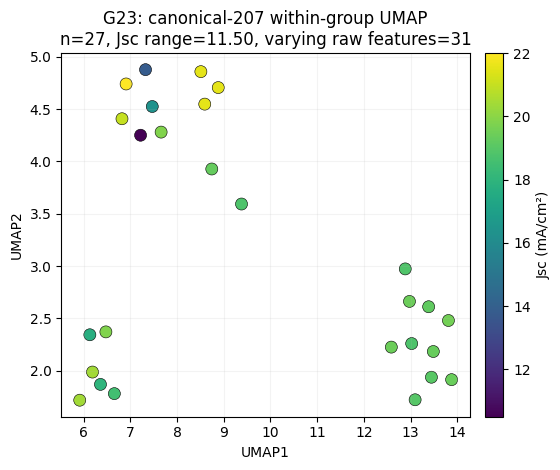


G26 | n=24 | Jsc range=11.02 mA/cm²
Varying canonical raw features: 2
['perovskite_deposition.thermal_annealing_temperature', 'perovskite_deposition.thermal_annealing_time']
Encoded dimensions: 4


/Users/rosylu/Desktop/Project/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


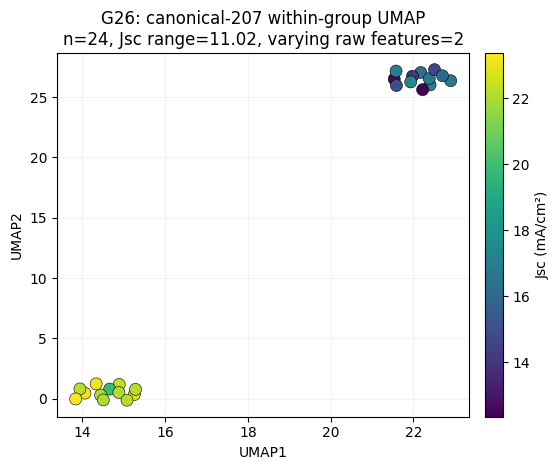


G21 | n=22 | Jsc range=11.72 mA/cm²
Varying canonical raw features: 24
['cell.stack_sequence', 'cell.area_measured', 'ETL_thickness_clean', 'etl.additives_compounds', 'perovskite_deposition.number_of_deposition_steps', 'perovskite_deposition.procedure', 'perovskite_deposition.aggregation_state_of_reactants', 'perovskite_deposition.synthesis_atmosphere', 'perovskite_deposition.solvents', 'perovskite_deposition.solvents_mixing_ratios', 'perovskite_deposition.quenching_induced_crystallisation', 'perovskite_deposition.quenching_media', 'perovskite_deposition.thermal_annealing_temperature', 'perovskite_deposition.thermal_annealing_time', 'backcontact.stack_sequence', 'BC_thickness_clean', 'backcontact.deposition_procedure', 'jv.average_over_n_number_of_cells', 'jv.test_atmosphere', 'HTL_thickness_clean', 'PVK_thickness_clean', 'BC_n_layers', 'Absorber_to_ETL_ratio', 'ff_PVK_fraction_of_total_stack']
Encoded dimensions: 56


/Users/rosylu/Desktop/Project/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


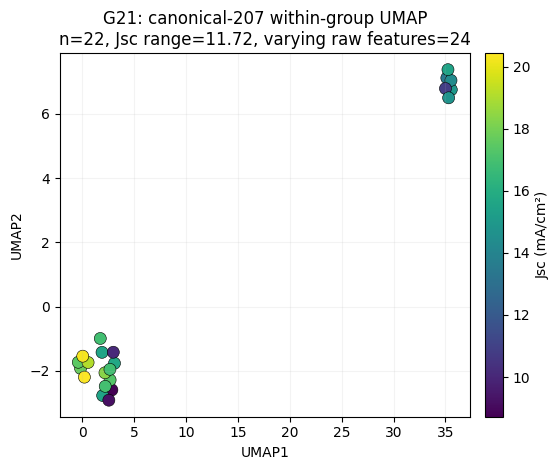


G13 | n=21 | Jsc range=13.23 mA/cm²
Varying canonical raw features: 11
['cell.area_measured', 'etl.additives_compounds', 'etl.deposition_procedure', 'perovskite_deposition.synthesis_atmosphere', 'perovskite_deposition.thermal_annealing_temperature', 'perovskite_deposition.thermal_annealing_time', 'jv.test_atmosphere', 'eqe.measured', 'stability.measured', 'stability.temperature_range', 'stability.atmosphere']
Encoded dimensions: 33


/Users/rosylu/Desktop/Project/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


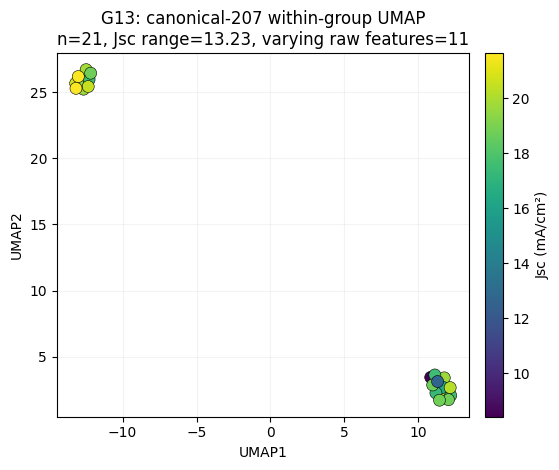


G8 | n=20 | Jsc range=18.18 mA/cm²
Varying canonical raw features: 4
['perovskite_deposition.thermal_annealing_temperature', 'perovskite_deposition.thermal_annealing_time', 'jv.average_over_n_number_of_cells', 'eqe.measured']
Encoded dimensions: 7


/Users/rosylu/Desktop/Project/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


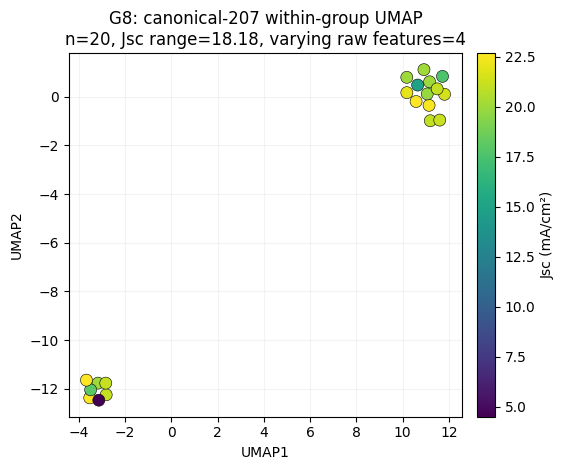


G9 | n=17 | Jsc range=15.87 mA/cm²
Varying canonical raw features: 24
['cell.stack_sequence', 'cell.area_measured', 'ETL_thickness_clean', 'etl.additives_compounds', 'perovskite_bandgap_clean', 'perovskite.band_gap_estimation_basis', 'perovskite_deposition.number_of_deposition_steps', 'perovskite_deposition.procedure', 'perovskite_deposition.aggregation_state_of_reactants', 'perovskite_deposition.synthesis_atmosphere', 'perovskite_deposition.solvents', 'perovskite_deposition.solvents_mixing_ratios', 'perovskite_deposition.quenching_induced_crystallisation', 'perovskite_deposition.quenching_media', 'perovskite_deposition.thermal_annealing_temperature', 'perovskite_deposition.thermal_annealing_time', 'backcontact.stack_sequence', 'BC_thickness_clean', 'jv.average_over_n_number_of_cells', 'jv.test_atmosphere', 'jv.light_spectra', 'eqe.measured', 'Absorber_to_ETL_ratio', 'ff_PVK_fraction_of_total_stack']
Encoded dimensions: 49


/Users/rosylu/Desktop/Project/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


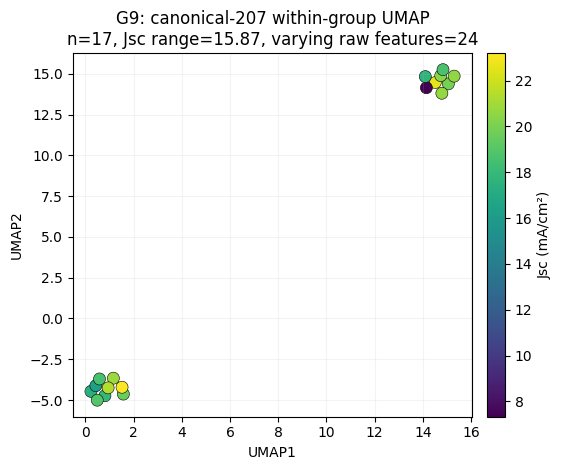


G16 | n=13 | Jsc range=12.71 mA/cm²
Varying canonical raw features: 7
['perovskite_deposition.number_of_deposition_steps', 'perovskite_deposition.procedure', 'perovskite_deposition.aggregation_state_of_reactants', 'perovskite_deposition.synthesis_atmosphere', 'perovskite_deposition.solvents', 'perovskite_deposition.solvents_mixing_ratios', 'perovskite_deposition.thermal_annealing_temperature']
Encoded dimensions: 29


/Users/rosylu/Desktop/Project/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


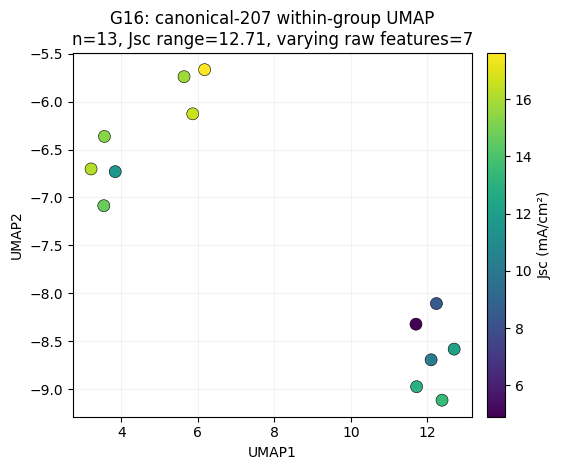


G28 | n=13 | Jsc range=10.93 mA/cm²
Varying canonical raw features: 23
['cell.stack_sequence', 'cell.area_measured', 'module.Module', 'module.number_of_cells_in_module', 'module.JV_data_recalculated_per_cell', 'substrate.stack_sequence', 'etl.deposition_procedure', 'perovskite_deposition.number_of_deposition_steps', 'perovskite_deposition.procedure', 'perovskite_deposition.aggregation_state_of_reactants', 'perovskite_deposition.synthesis_atmosphere', 'perovskite_deposition.solvents', 'perovskite_deposition.solvents_mixing_ratios', 'perovskite_deposition.quenching_induced_crystallisation', 'perovskite_deposition.quenching_media', 'perovskite_deposition.thermal_annealing_temperature', 'perovskite_deposition.thermal_annealing_time', 'htl.deposition_procedure', 'BC_thickness_clean', 'jv.average_over_n_number_of_cells', 'jv.test_atmosphere', 'eqe.measured', 'ff_PVK_fraction_of_total_stack']
Encoded dimensions: 45


/Users/rosylu/Desktop/Project/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


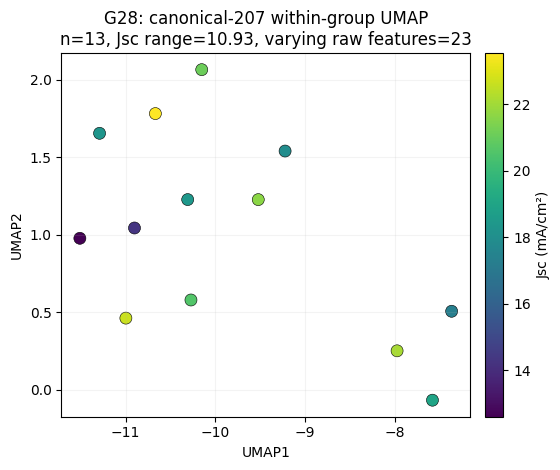


G24 | n=12 | Jsc range=11.34 mA/cm²
Varying canonical raw features: 1
['jv.average_over_n_number_of_cells']
Encoded dimensions: 1
Descriptor-insufficient: fewer than two encoded varying dimensions remain after canonical feature filtering.

G32 | n=12 | Jsc range=10.40 mA/cm²
Varying canonical raw features: 4
['perovskite_bandgap_clean', 'perovskite.band_gap_estimation_basis', 'jv.default_PCE_scan_direction', 'stabilised.performance_measured']
Encoded dimensions: 7


/Users/rosylu/Desktop/Project/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


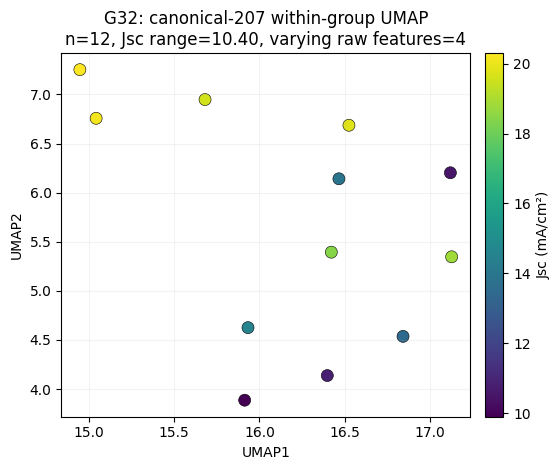


G20 | n=11 | Jsc range=11.99 mA/cm²
Varying canonical raw features: 7
['cell.area_measured', 'ETL_thickness_clean', 'perovskite_deposition.procedure', 'perovskite_deposition.solvents_mixing_ratios', 'perovskite_deposition.quenching_media', 'Absorber_to_ETL_ratio', 'ff_PVK_fraction_of_total_stack']
Encoded dimensions: 10


/Users/rosylu/Desktop/Project/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


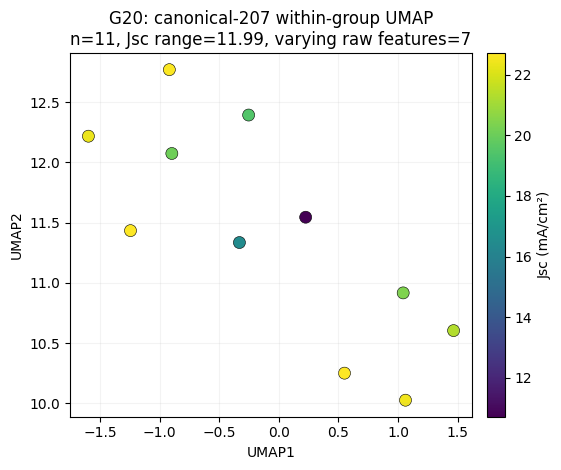


G22 | n=11 | Jsc range=11.68 mA/cm²
Varying canonical raw features: 3
['ETL_thickness_clean', 'Absorber_to_ETL_ratio', 'ff_PVK_fraction_of_total_stack']
Encoded dimensions: 3


/Users/rosylu/Desktop/Project/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


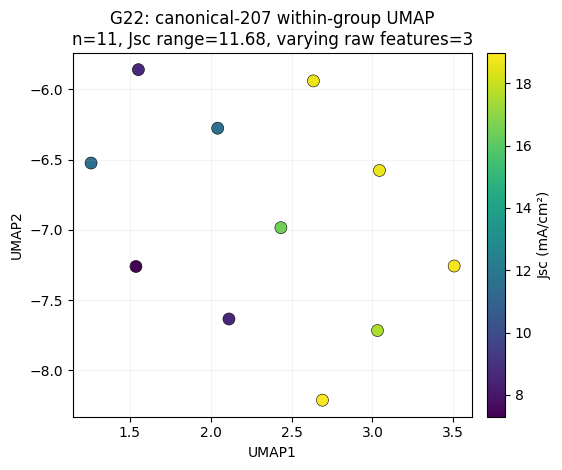


G4 | n=10 | Jsc range=19.57 mA/cm²
Varying canonical raw features: 8
['cell.stack_sequence', 'cell.flexible', 'substrate.stack_sequence', 'jv.average_over_n_number_of_cells', 'jv.light_intensity', 'jv.light_spectra', 'jv.default_PCE_scan_direction', 'stabilised.performance_measured']
Encoded dimensions: 14


/Users/rosylu/Desktop/Project/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


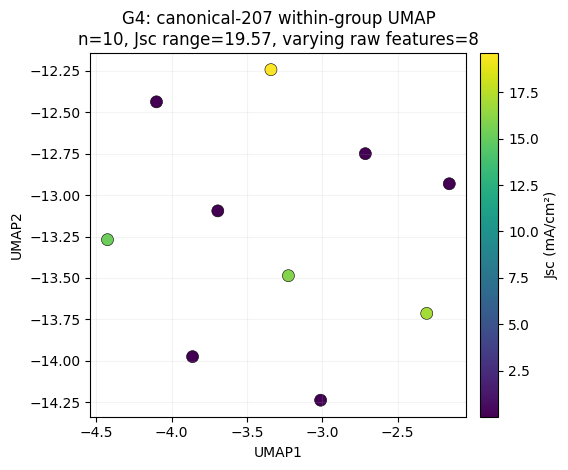


G7 | n=10 | Jsc range=18.49 mA/cm²
Varying canonical raw features: 7
['encapsulation.stack_sequence', 'encapsulation.edge_sealing_materials', 'jv.average_over_n_number_of_cells', 'eqe.measured', 'PVK_thickness_clean', 'Absorber_to_ETL_ratio', 'ff_PVK_fraction_of_total_stack']
Encoded dimensions: 10


/Users/rosylu/Desktop/Project/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


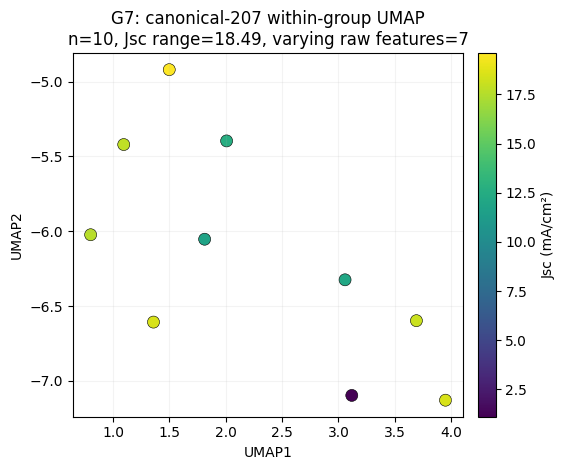


G10 | n=10 | Jsc range=14.20 mA/cm²
Varying canonical raw features: 2
['cell.area_measured', 'jv.average_over_n_number_of_cells']
Encoded dimensions: 2


/Users/rosylu/Desktop/Project/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


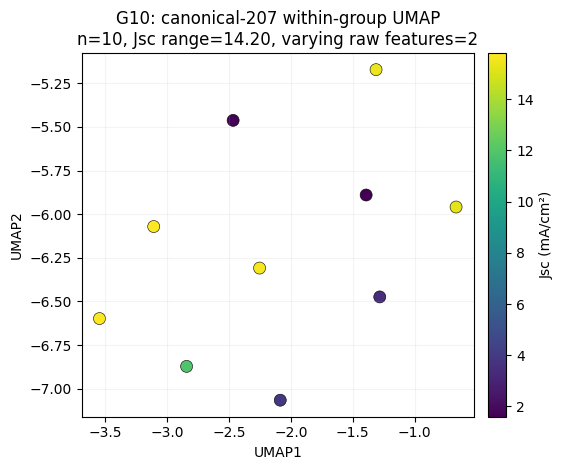


G17 | n=10 | Jsc range=12.47 mA/cm²
Varying canonical raw features: 0
[]
Encoded dimensions: 0
Descriptor-insufficient: fewer than two encoded varying dimensions remain after canonical feature filtering.

G31 | n=10 | Jsc range=10.52 mA/cm²
Varying canonical raw features: 15
['cell.stack_sequence', 'substrate.stack_sequence', 'etl.additives_compounds', 'perovskite.band_gap_estimation_basis', 'perovskite_deposition.synthesis_atmosphere', 'perovskite_deposition.thermal_annealing_temperature', 'perovskite_deposition.thermal_annealing_time', 'backcontact.stack_sequence', 'BC_thickness_clean', 'jv.average_over_n_number_of_cells', 'jv.light_spectra', 'PVK_thickness_clean', 'BC_n_layers', 'Absorber_to_ETL_ratio', 'ff_PVK_fraction_of_total_stack']
Encoded dimensions: 26


/Users/rosylu/Desktop/Project/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


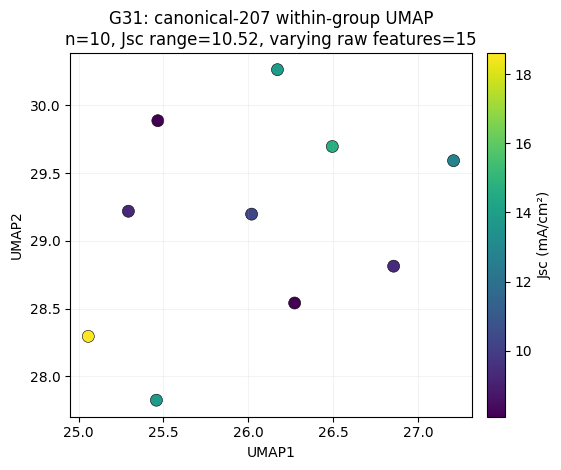

,group_id,n,jsc_min,jsc_max,jsc_range,projection_status,varying_raw_features_n,encoded_dimensions_n,varying_features
0,G23,27,10.500,22.000,11.500,UMAP produced,31,62,cell.stack_sequence; cell.area_measured; cell....
1,G26,24,12.350,23.370,11.020,UMAP produced,2,4,perovskite_deposition.thermal_annealing_temper...
2,G21,22,8.720,20.440,11.720,UMAP produced,24,56,cell.stack_sequence; cell.area_measured; ETL_t...
3,G13,21,8.420,21.650,13.230,UMAP produced,11,33,cell.area_measured; etl.additives_compounds; e...
4,G8,20,4.500,22.680,18.180,UMAP produced,4,7,perovskite_deposition.thermal_annealing_temper...
5,G9,17,7.330,23.200,15.870,UMAP produced,24,49,cell.stack_sequence; cell.area_measured; ETL_t...
6,G16,13,4.900,17.610,12.710,UMAP produced,7,29,perovskite_deposition.number_of_deposition_ste...
7,G28,13,12.610,23.540,10.930,UMAP produced,23,45,cell.stack_sequence; cell.area_measured; modul...
8,G24,12,8.170,19.510,11.340,descriptor-insufficient,1,1,jv.average_over_n_number_of_cells
9,G32,12,9.900,20.300,10.400,UMAP produced,4,7,perovskite_bandgap_clean; perovskite.band_gap_...


In [6]:
# ============================================================
# 4. Jsc within-group UMAP
# ============================================================

def plot_jsc_group_umap(group_id):
    sub = (
        df_jsc_diagnosis[
            df_jsc_diagnosis["group_id"] == group_id
        ]
        .copy()
        .reset_index(drop=True)
    )

    if sub.empty:
        print(f"{group_id}: no rows found.")
        return {
            "group_id": group_id,
            "n": 0,
            "jsc_min": np.nan,
            "jsc_max": np.nan,
            "jsc_range": np.nan,
            "projection_status": "no rows",
            "varying_raw_features_n": 0,
            "encoded_dimensions_n": 0,
            "varying_features": "",
        }

    matrix, used_features, encoded_names = make_embedding_matrix(
        sub,
        ALLIN_FEATURES,
    )
    y = sub["_jsc"].to_numpy(dtype=float)

    print("\n" + "=" * 100)
    print(
        f"{group_id} | n={len(sub)} | "
        f"Jsc range={np.ptp(y):.2f} mA/cm²"
    )
    print("Varying canonical raw features:", len(used_features))
    print(used_features)
    print("Encoded dimensions:", matrix.shape[1])

    if matrix.shape[1] < 2:
        print(
            "Descriptor-insufficient: fewer than two encoded varying "
            "dimensions remain after canonical feature filtering."
        )
        return {
            "group_id": group_id,
            "n": len(sub),
            "jsc_min": float(np.min(y)),
            "jsc_max": float(np.max(y)),
            "jsc_range": float(np.ptp(y)),
            "projection_status": "descriptor-insufficient",
            "varying_raw_features_n": len(used_features),
            "encoded_dimensions_n": int(matrix.shape[1]),
            "varying_features": "; ".join(used_features),
        }

    n_neighbors = min(UMAP_MAX_NEIGHBORS, len(sub) - 1)

    umap_model = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=UMAP_MIN_DIST,
        random_state=RANDOM_STATE,
    )
    coordinates = umap_model.fit_transform(matrix)

    figure, axis = plt.subplots(figsize=(5.8, 4.8))

    scatter = axis.scatter(
        coordinates[:, 0],
        coordinates[:, 1],
        c=y,
        cmap="viridis",
        s=75,
        edgecolor="black",
        linewidth=0.4,
    )


    axis.set_title(
        f"{group_id}: canonical-207 within-group UMAP\n"
        f"n={len(sub)}, Jsc range={np.ptp(y):.2f}, "
        f"varying raw features={len(used_features)}"
    )
    axis.set_xlabel("UMAP1")
    axis.set_ylabel("UMAP2")
    axis.grid(alpha=0.15)

    colorbar = figure.colorbar(
        scatter,
        ax=axis,
        pad=0.03,
    )
    colorbar.set_label("Jsc (mA/cm²)")

    figure.tight_layout()
    figure.savefig(
        OUTPUT_DIR / f"{group_id}_jsc_canonical207_umap.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    return {
        "group_id": group_id,
        "n": len(sub),
        "jsc_min": float(np.min(y)),
        "jsc_max": float(np.max(y)),
        "jsc_range": float(np.ptp(y)),
        "projection_status": "UMAP produced",
        "varying_raw_features_n": len(used_features),
        "encoded_dimensions_n": int(matrix.shape[1]),
        "varying_features": "; ".join(used_features),
    }


jsc_projection_rows = [
    plot_jsc_group_umap(group_id)
    for group_id in JSC_ANALYSIS_GROUPS
]

jsc_projection_summary = pd.DataFrame(jsc_projection_rows)
display(jsc_projection_summary)

jsc_projection_summary.to_csv(
    OUTPUT_DIR / "jsc_projection_summary.csv",
    index=False,
)


## 5. Canonical-feature variation inventory

This table records the descriptors that actually vary in each selected Jsc group. It is the principal interpretation aid for the UMAP plots.

No reference identity fields or measured outcome fields are included because they are absent from the canonical 207 predictor space.


In [7]:
# ============================================================
# 5. Jsc varying-feature inventory
# ============================================================

def feature_value_preview(series, max_values=12):
    if pd.api.types.is_numeric_dtype(series):
        values = pd.unique(series.dropna())
    else:
        values = pd.unique(
            normalise_categorical_missing(series)
            .fillna("Missing")
        )

    preview = [
        str(value)
        for value in values[:max_values]
    ]

    if len(values) > max_values:
        preview.append("...")

    return "; ".join(preview)


variation_rows = []

for group_id in JSC_ANALYSIS_GROUPS:
    sub = (
        df_jsc_diagnosis[
            df_jsc_diagnosis["group_id"] == group_id
        ]
        .copy()
        .reset_index(drop=True)
    )

    used_features = varying_features(
        sub,
        ALLIN_FEATURES,
    )

    for feature in used_features:
        series = sub[feature]

        if pd.api.types.is_numeric_dtype(series):
            n_unique = series.dropna().nunique()
        else:
            n_unique = (
                normalise_categorical_missing(series)
                .fillna("Missing")
                .nunique(dropna=False)
            )

        variation_rows.append({
            "group_id": group_id,
            "n": len(sub),
            "jsc_range": (
                sub["_jsc"].max()
                - sub["_jsc"].min()
            ),
            "feature": feature,
            "feature_type": (
                "numeric"
                if pd.api.types.is_numeric_dtype(series)
                else "categorical"
            ),
            "n_unique": int(n_unique),
            "values": feature_value_preview(series),
        })

jsc_feature_variation = pd.DataFrame(variation_rows)

display(jsc_feature_variation)

jsc_feature_variation.to_csv(
    OUTPUT_DIR / "jsc_canonical207_group_feature_variation.csv",
    index=False,
)


,group_id,n,jsc_range,feature,feature_type,n_unique,values
0,G23,27,11.50,cell.stack_sequence,categorical,3,SLG | FTO | TiO2-c | Perovskite | Spiro-MeOTAD...
1,G23,27,11.50,cell.area_measured,numeric,2,0.16; 0.1
2,G23,27,11.50,cell.semitransparent,categorical,2,False; True
3,G23,27,11.50,substrate.stack_sequence,categorical,2,SLG | FTO; SLG | ITO
4,G23,27,11.50,ETL_thickness_clean,numeric,2,50.0; 30.0
...,...,...,...,...,...,...,...
168,G31,10,10.52,jv.light_spectra,categorical,2,Missing; AM 1.5
169,G31,10,10.52,PVK_thickness_clean,numeric,2,240.0; 230.0
170,G31,10,10.52,BC_n_layers,numeric,2,2; 5
171,G31,10,10.52,Absorber_to_ETL_ratio,numeric,2,4.363636363636363; 4.181818181818182


## 6. Voc similar-device inconsistency audit

Voc is used here only as a secondary consistency check.

Its established grouping rule is slightly stricter than the Jsc rule because the back-contact stack is also held constant. The audit reports groups with:

- `n >= 5`
- Voc range `> 0.3 V`

No Voc UMAP categories are generated in this notebook. A full Voc diagnosis should only be added if it produces a distinct mechanistic conclusion rather than duplicating the Jsc analysis.


In [8]:
# ============================================================
# 6. Compact Voc audit
# ============================================================

VOC_TARGET = "jv.default_Voc"

df_voc = df.dropna(subset=[VOC_TARGET]).copy()
df_voc["_voc"] = pd.to_numeric(df_voc[VOC_TARGET], errors="coerce")

df_voc["bandgap_bin"] = (
    df_voc["perovskite_bandgap_clean"] / 0.05
).round() * 0.05
df_voc["PVK_bin"] = (
    df_voc["PVK_thickness_clean"] / 50
).round() * 50
df_voc["ETL_bin"] = (
    df_voc["ETL_thickness_clean"] / 20
).round() * 20
df_voc["HTL_bin"] = (
    df_voc["HTL_thickness_clean"] / 20
).round() * 20

VOC_GROUP_COLUMNS = [
    "perovskite.composition_short_form",
    "cell.architecture",
    "etl.stack_sequence",
    "htl.stack_sequence",
    "backcontact.stack_sequence",
    "bandgap_bin",
    "PVK_bin",
    "ETL_bin",
    "HTL_bin",
]

voc_group_input = df_voc.dropna(
    subset=VOC_GROUP_COLUMNS + ["_voc"]
).copy()

voc_group_stats = (
    voc_group_input
    .groupby(VOC_GROUP_COLUMNS)["_voc"]
    .agg(
        n="count",
        mean="mean",
        std="std",
        min="min",
        max="max",
    )
    .reset_index()
)
voc_group_stats["range"] = (
    voc_group_stats["max"] - voc_group_stats["min"]
)
voc_group_stats["inconsistent_group"] = (
    (voc_group_stats["n"] >= VOC_AUDIT_MIN_N)
    & (voc_group_stats["range"] > VOC_RANGE_THRESHOLD)
)

voc_inconsistent_groups = (
    voc_group_stats[
        voc_group_stats["inconsistent_group"]
    ]
    .sort_values(
        ["range", "n"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

print("Voc audit rule:")
print(f"  n >= {VOC_AUDIT_MIN_N}")
print(f"  Voc range > {VOC_RANGE_THRESHOLD:.2f} V")
print("Inconsistent Voc groups:", len(voc_inconsistent_groups))
print(
    "Rows represented by inconsistent groups:",
    int(voc_inconsistent_groups["n"].sum())
)

display(
    voc_inconsistent_groups[
        ["n", "mean", "std", "min", "max", "range"]
        + VOC_GROUP_COLUMNS
    ]
)

voc_group_stats.to_csv(
    OUTPUT_DIR / "voc_all_similar_device_group_stats.csv",
    index=False,
)
voc_inconsistent_groups.to_csv(
    OUTPUT_DIR / "voc_inconsistent_group_audit.csv",
    index=False,
)


Voc audit rule:
  n >= 5
  Voc range > 0.30 V
Inconsistent Voc groups: 20
Rows represented by inconsistent groups: 182


,n,mean,std,min,max,range,perovskite.composition_short_form,cell.architecture,etl.stack_sequence,htl.stack_sequence,backcontact.stack_sequence,bandgap_bin,PVK_bin,ETL_bin,HTL_bin
0,6,0.204667,0.448420,0.021,1.120,1.099,CsFAMAPbBrI,nip,TiO2-c | SnO2-np,Spiro-MeOTAD,Au,1.65,500.0,40.0,200.0
1,6,0.163667,0.360731,0.014,0.900,0.886,MAPbI,nip,TiO2-c | TiO2-mp,Spiro-MeOTAD,Au,1.60,300.0,560.0,200.0
2,5,0.676000,0.377929,0.000,0.850,0.850,MAPbI,pin,LiSPS | PCBM-60,PEDOT:PSS,Al,1.50,300.0,100.0,40.0
3,7,0.901429,0.225346,0.420,1.110,0.690,MAPbI,pin,PCBM-60,PEDOT:PSS,Al,1.60,300.0,40.0,40.0
4,5,0.829800,0.273578,0.350,1.023,0.673,MAPbI,nip,TiO2-c | TiO2-mp,Spiro-MeOTAD,Au,1.60,150.0,240.0,200.0
5,5,0.746000,0.242136,0.370,0.960,0.590,MAPbI,pin,PCBM-60 | bis-C60,PEDOT:PSS,Ag,1.60,350.0,120.0,40.0
6,14,0.922143,0.160680,0.600,1.100,0.500,MAPbI,nip,SnO2-c,Spiro-MeOTAD,Ag,1.60,250.0,20.0,80.0
7,29,1.034517,0.111081,0.809,1.280,0.471,MAAgPbBr,nip,TiO2-c | TiO2-mp,Spiro-MeOTAD,Au,2.30,400.0,300.0,200.0
8,8,0.954375,0.138464,0.638,1.085,0.447,MAPbI,nip,TiO2-c,Spiro-MeOTAD,Au,1.60,500.0,40.0,160.0
9,9,0.922111,0.184797,0.690,1.120,0.430,MAPbI,nip,TiO2-c,PTAA,Au,1.60,350.0,40.0,60.0


## Interpretation boundary

This notebook supports the following claims only:

1. Large target variation exists among devices that are similar under the principal recorded material/device descriptors.
2. Some Jsc groups contain remaining descriptor structure that aligns with Jsc; others contain mixed structure or too little recorded variation.
3. The canonical feature inventory can identify which mechanisms are represented and which remain absent.

It does **not** establish causality, automatically classify groups, or prove that a visually separated UMAP pattern will generalise predictively.
